In [1]:
# import general libraries
import numpy as np
import pandas as pd
import sklearn as sk
import xgboost as xg
import seaborn as sns
import matplotlib.pyplot as plt
import catboost as cat

# import specific functions/libraries
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from catboost import CatBoostClassifier

In [2]:
# read in data
train_df = pd.read_csv(r"C:\Users\miria\OneDrive\Documents\DS Learn\input datasets\spaceshiptitanic\train.csv")
test_df = pd.read_csv(r"C:\Users\miria\OneDrive\Documents\DS Learn\input datasets\spaceshiptitanic\test.csv")

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
train_df.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
train_df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [6]:
# EDA and deciding how to handle missing values for each column

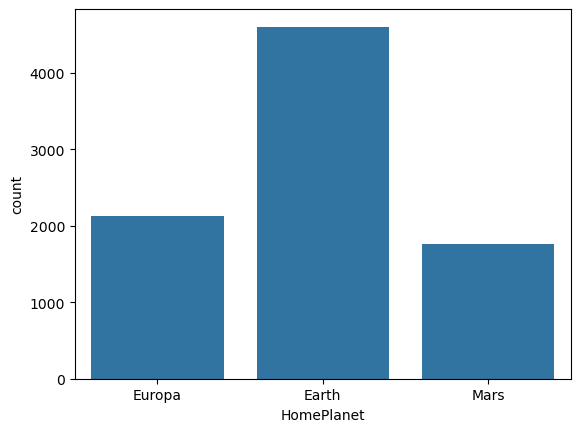

In [7]:
# column: HomePlanet

train_df['HomePlanet'].unique()

sns.countplot(x = 'HomePlanet', data = train_df)

# impute with mode
train_df['HomePlanet'] = train_df['HomePlanet'].fillna(train_df['HomePlanet'].mode())
test_df['HomePlanet'] = test_df['HomePlanet'].fillna(test_df['HomePlanet'].mode())

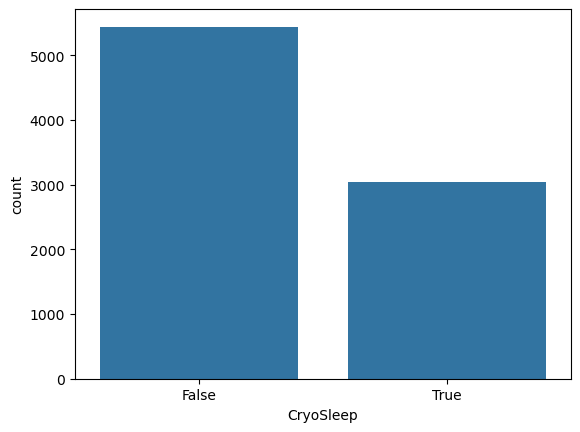

In [8]:
# column: CryoSleep (bool)

sns.countplot(x = 'CryoSleep', data = train_df)

# impute with mode
train_df['CryoSleep'] = train_df['CryoSleep'].fillna(train_df['CryoSleep'].mode())
test_df['CryoSleep'] = test_df['CryoSleep'].fillna(test_df['CryoSleep'].mode())

In [9]:
# column: Cabin (object)

train_df['Cabin'].value_counts()

# replace na values with NA string
train_df['Cabin'] = train_df['Cabin'].fillna('NA/NA/NA')
test_df['Cabin'] = test_df['Cabin'].fillna('NA/NA/NA')

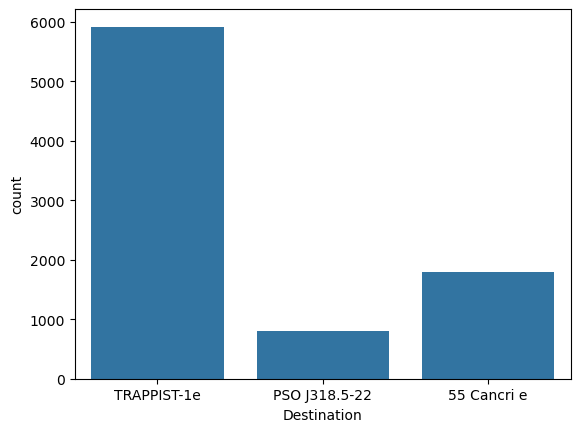

In [10]:
# column: Destination (object)

sns.countplot(x = 'Destination', data = train_df)

# there is a clear superiority in frequency: impute with mode
train_df['Destination'] = train_df['Destination'].fillna(train_df['Destination'].mode()[0])
test_df['Destination'] = test_df['Destination'].fillna(test_df['Destination'].mode()[0])

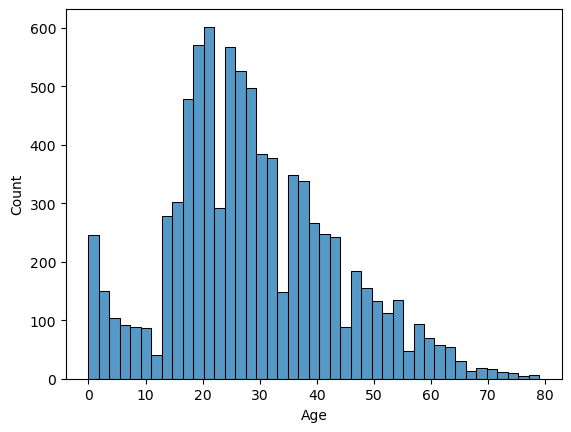

In [11]:
# column: Age (float)

sns.histplot(data = train_df, x = 'Age')

# distribution is skewed: impute with median
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

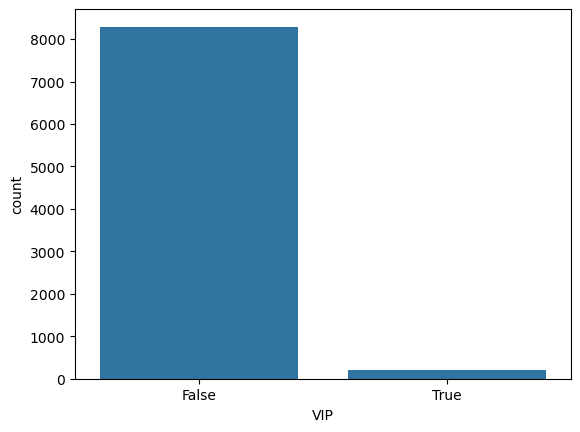

In [12]:
# column: VIP (bool)
sns.countplot(x = 'VIP', data = train_df)

# very small amount of passengers are VIP: safe to impute with mode
train_df['VIP'] = train_df['VIP'].fillna(train_df['VIP'].mode())
test_df['VIP'] = test_df['VIP'].fillna(test_df['VIP'].mode())

In [13]:
# column: RoomService (float)

train_df['RoomService'].value_counts()

# since most values in this column are 0.0, will be imputing with median (which in this case is also the mode)
train_df['RoomService'] = train_df['RoomService'].fillna(train_df['RoomService'].median())
test_df['RoomService'] = test_df['RoomService'].fillna(test_df['RoomService'].median())

In [14]:
# column: FoodCourt (float)

train_df['FoodCourt'].value_counts()

# same case as RoomService: most are 0.0 and as such, will be imputing with median
train_df['FoodCourt'] = train_df['FoodCourt'].fillna(train_df['FoodCourt'].median())
test_df['FoodCourt'] = test_df['FoodCourt'].fillna(test_df['FoodCourt'].median())

In [15]:
# column: ShoppingMall (float)

train_df['ShoppingMall'].value_counts()

# same case as RoomService: most are 0.0 and as such, will be imputing with median
train_df['ShoppingMall'] = train_df['ShoppingMall'].fillna(train_df['ShoppingMall'].median())
test_df['ShoppingMall'] = test_df['ShoppingMall'].fillna(test_df['ShoppingMall'].median())

In [16]:
# column: Spa (float)

train_df['Spa'].value_counts()

# same case as RoomService: most are 0.0 and as such, will be imputing with median
train_df['Spa'] = train_df['Spa'].fillna(train_df['Spa'].median())
test_df['Spa'] = test_df['Spa'].fillna(test_df['Spa'].median())

In [17]:
# column: VRDeck (float)

train_df['VRDeck'].value_counts()

# same case as RoomService: most are 0.0 and as such, will be imputing with median
train_df['VRDeck'] = train_df['VRDeck'].fillna(train_df['VRDeck'].median())
test_df['VRDeck'] = test_df['VRDeck'].fillna(test_df['VRDeck'].median())

In [18]:
# Feature Engineering

In [19]:
# first drop name and passengerid as theyre not necessary for model training
train_df = train_df.drop(['Name'], axis=1)
test_df = test_df.drop(['Name'], axis=1)

In [20]:
# feature engineering: create new features

# boolean for if passenger spent any money on a commodity at all
train_df['SpentMoney'] = ((train_df['Spa'] > 0.0) | (train_df['VRDeck'] > 0.0) | (train_df['RoomService'] > 0.0) |(train_df['ShoppingMall'] > 0.0) | (train_df['FoodCourt'] > 0.0))
test_df['SpentMoney'] = ((test_df['Spa'] > 0.0) | (test_df['VRDeck'] > 0.0) | (test_df['RoomService'] > 0.0) |(test_df['ShoppingMall'] > 0.0) | (test_df['FoodCourt'] > 0.0))

# total money spent
train_df['MoneySpent'] = train_df['Spa'] + train_df['VRDeck'] + train_df['RoomService'] + train_df['ShoppingMall'] + train_df['FoodCourt']
test_df['MoneySpent'] = test_df['Spa'] + test_df['VRDeck'] + test_df['RoomService'] + test_df['ShoppingMall'] + test_df['FoodCourt']

# age category
def agecategoryfunc(row):
    cat = ''
    if row['Age'] < 18:
        cat = 'Minor'
    elif (row['Age'] >= 18) & (row['Age'] <= 40):
        cat = 'Adult'
    else:
        cat = 'Senior'
    return cat
train_df['AgeCategory'] = train_df.apply(agecategoryfunc, axis=1)
test_df['AgeCategory'] = test_df.apply(agecategoryfunc, axis=1)

In [21]:
# family features

# familyid (using passengerid)
def cabinnumfunc(passenger_id):
    try:
        return passenger_id.split('_')[0]
    except:
        return np.nan
train_df['FamilyId'] = train_df['PassengerId'].apply(cabinnumfunc)
test_df['FamilyId'] = test_df['PassengerId'].apply(cabinnumfunc)

# Calculate family size based on the room number
train_df['FamilySize'] = train_df.groupby('FamilyId')['PassengerId'].transform('count')
test_df['FamilySize'] = test_df.groupby('FamilyId')['PassengerId'].transform('count')

# Creating 'IsFamily'
train_df['IsFamily'] = train_df['FamilySize'].apply(lambda x: 1 if x > 1 else 0)
test_df['IsFamily'] = test_df['FamilySize'].apply(lambda x: 1 if x > 1 else 0)

In [22]:
# feature engineering: split 'Cabin' column (formatted as deck/num/side) into deck, num, and side
train_df[['Deck', 'CabinNum', 'Side']] =  train_df['Cabin'].str.split('/', expand=True)
test_df[['Deck', 'CabinNum', 'Side']] =  test_df['Cabin'].str.split('/', expand=True)

train_df = train_df.drop(['Cabin', 'CabinNum'], axis=1)
test_df = test_df.drop(['Cabin', 'CabinNum'], axis=1)

In [23]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Destination   8693 non-null   object 
 4   Age           8693 non-null   float64
 5   VIP           8490 non-null   object 
 6   RoomService   8693 non-null   float64
 7   FoodCourt     8693 non-null   float64
 8   ShoppingMall  8693 non-null   float64
 9   Spa           8693 non-null   float64
 10  VRDeck        8693 non-null   float64
 11  Transported   8693 non-null   bool   
 12  SpentMoney    8693 non-null   bool   
 13  MoneySpent    8693 non-null   float64
 14  AgeCategory   8693 non-null   object 
 15  FamilyId      8693 non-null   object 
 16  FamilySize    8693 non-null   int64  
 17  IsFamily      8693 non-null   int64  
 18  Deck          8693 non-null 

In [24]:
# use mutual info regression to extract mi scores (indicators of significance/correlation for each feature w/ target)

X = train_df.copy()
y = X.pop("Transported")

# label encoding for categoricals
for colname in X.select_dtypes("object"):
    X[colname], _ = X[colname].factorize()

mi_scores = mutual_info_regression(X, y, discrete_features = 'auto')
mi_scores = pd.Series(mi_scores, name = "MI Scores", index = X.columns).sort_values(ascending = False)

# print out all values
pd.set_option('display.max_rows', 20)
mi_scores

MoneySpent      0.132053
SpentMoney      0.123358
CryoSleep       0.111061
RoomService     0.066527
Spa             0.064299
VRDeck          0.064081
FoodCourt       0.048710
ShoppingMall    0.033297
Deck            0.031310
FamilyId        0.020157
FamilySize      0.017600
PassengerId     0.017259
Age             0.015390
Side            0.013482
HomePlanet      0.012818
IsFamily        0.012673
VIP             0.008478
AgeCategory     0.005483
Destination     0.000654
Name: MI Scores, dtype: float64

In [25]:
# list of features
features = ['HomePlanet', 'CryoSleep', 'Deck', 'Destination', 'Age', 'Side', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'SpentMoney', 'MoneySpent', 'IsFamily']

# set X and y
X = train_df[features]
y = train_df['Transported']

In [26]:
# encode categorical variables
categorical_features = X.select_dtypes(include = ['object']).columns.tolist()

X = pd.get_dummies(X, columns = categorical_features, dtype = int)
test_df = pd.get_dummies(test_df, columns = categorical_features, dtype = int)

In [27]:
# use train_test_split to prep data
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state = 0)

In [28]:
# create catboost classifier model
model = CatBoostClassifier(iterations = 1000, 
                           learning_rate = 0.1, 
                           depth = 6,
                           eval_metric = "Accuracy",
                           verbose = 100)

# set parameters for model
params = {
    'depth': [4,6,8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [500, 1000, 1500]
}

grid_search = GridSearchCV(model, 
                           params, 
                           cv=5, 
                           scoring = 'accuracy')

# fit gridsearch (model) on data
grid_search.fit(train_X, train_y)
best = grid_search.best_estimator_

0:	learn: 0.7499521	total: 167ms	remaining: 1m 23s
100:	learn: 0.7720038	total: 754ms	remaining: 2.98s
200:	learn: 0.7940556	total: 1.12s	remaining: 1.67s
300:	learn: 0.8026846	total: 1.39s	remaining: 920ms
400:	learn: 0.8028763	total: 1.68s	remaining: 415ms
499:	learn: 0.8051774	total: 1.95s	remaining: 0us
0:	learn: 0.7574305	total: 5.34ms	remaining: 2.66s
100:	learn: 0.7896453	total: 301ms	remaining: 1.19s
200:	learn: 0.7976989	total: 567ms	remaining: 844ms
300:	learn: 0.8044104	total: 863ms	remaining: 571ms
400:	learn: 0.8078619	total: 1.13s	remaining: 279ms
499:	learn: 0.8101630	total: 1.4s	remaining: 0us
0:	learn: 0.7390221	total: 6.1ms	remaining: 3.04s
100:	learn: 0.7758389	total: 322ms	remaining: 1.27s
200:	learn: 0.7936721	total: 608ms	remaining: 904ms
300:	learn: 0.7982742	total: 873ms	remaining: 577ms
400:	learn: 0.8024928	total: 1.17s	remaining: 289ms
499:	learn: 0.8076702	total: 1.44s	remaining: 0us
0:	learn: 0.7418984	total: 8.7ms	remaining: 4.34s
100:	learn: 0.7700863	tot

In [29]:
# make prediction and print mean absolute error
train_pred = best.predict(val_X)
initial_acc = accuracy_score(val_y, train_pred)
print(initial_acc)

0.8118675252989881


In [30]:
# fit gridsearch (model) on all training data
grid_search.fit(X, y)
best = grid_search.best_estimator_

0:	learn: 0.7404372	total: 8.9ms	remaining: 4.44s
100:	learn: 0.7710670	total: 851ms	remaining: 3.36s
200:	learn: 0.7946506	total: 1.56s	remaining: 2.33s
300:	learn: 0.8001150	total: 2.35s	remaining: 1.56s
400:	learn: 0.8038539	total: 3.35s	remaining: 827ms
499:	learn: 0.8103250	total: 4.21s	remaining: 0us
0:	learn: 0.7430256	total: 10.9ms	remaining: 5.44s
100:	learn: 0.7769629	total: 862ms	remaining: 3.41s
200:	learn: 0.7953696	total: 1.86s	remaining: 2.77s
300:	learn: 0.7979580	total: 2.82s	remaining: 1.86s
400:	learn: 0.8012655	total: 3.78s	remaining: 934ms
499:	learn: 0.8058671	total: 4.77s	remaining: 0us
0:	learn: 0.7417314	total: 10ms	remaining: 4.99s
100:	learn: 0.7722174	total: 774ms	remaining: 3.06s
200:	learn: 0.7888985	total: 1.82s	remaining: 2.71s
300:	learn: 0.7965200	total: 2.83s	remaining: 1.87s
400:	learn: 0.8009779	total: 3.76s	remaining: 929ms
499:	learn: 0.8027035	total: 4.75s	remaining: 0us
0:	learn: 0.7378864	total: 9.15ms	remaining: 4.57s
100:	learn: 0.7656362	tot

In [31]:
test_X = test_df[train_X.columns]

# make predictions on test data
test_pred = best.predict(test_X)

In [32]:
# ensure predictions are output as True or False
test_pred = test_pred.astype(bool)

# save predictions as csv file for submission
output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Transported': test_pred})
output.to_csv(r"C:\Users\miria\OneDrive\Documents\DS Learn\output datasets\spaceshipsubmissions1.csv", index=False)